# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [1]:
from statistics import linear_regression

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.
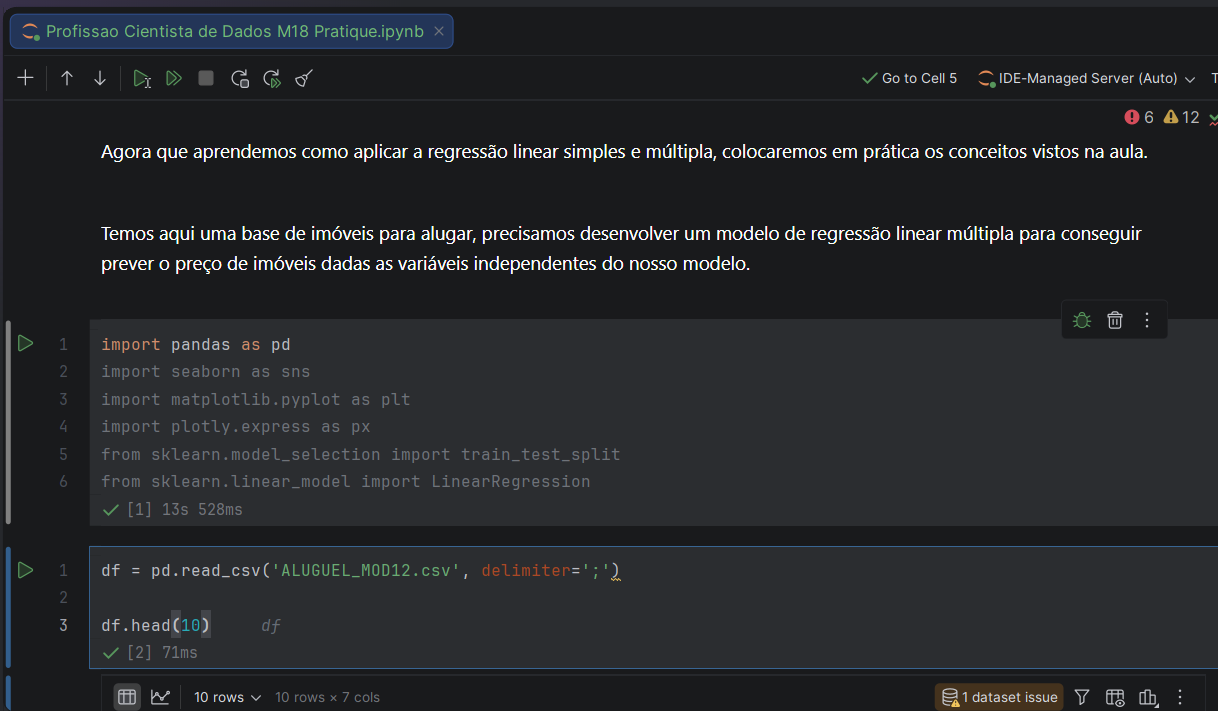

In [3]:
# Verificação dos tipos dos dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB


In [4]:
# Verificação de dados faltantes por coluna
print("Quantidade de dados faltantes por coluna:")
print(df.isna().sum())

Quantidade de dados faltantes por coluna:
Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64


d**JUSTIFICATIVA:** A verificação identificou 0 valores nulos em todas as colunas. Portanto, nenhuma imutação de dados ou remoção foi necessária, preservando a totalidade do dataset.

# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [5]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


In [6]:
# Análise e tratamento de outliers
q1_aluguel = df['Valor_Aluguel'].quantile(0.25)
q3_aluguel = df['Valor_Aluguel'].quantile(0.75)
iqr_aluguel = q3_aluguel - q1_aluguel
lim_superior_aluguel = q3_aluguel + (1.5 * iqr_aluguel)

q1_metragem = df['Metragem'].quantile(0.25)
q3_metragem = df['Metragem'].quantile(0.75)
iqr_metragem = q3_metragem - q1_metragem
lim_superior_metragem = q3_metragem + (1.5 * iqr_metragem)

# Outliers: Filtragem e remoção
df_clean = df[(df['Valor_Aluguel'] <= lim_superior_aluguel) & (df['Metragem'] >= lim_superior_metragem)].copy()

print(f"Linhas antes do tratamento: {len(df)}")
print(f"Linhas depois do tratamento: {len(df_clean)}")

Linhas antes do tratamento: 7203
Linhas depois do tratamento: 227


**JUSTIFICATIVA:** A escolha pelo intervalo interquartil (IQR) se dá pelo fato de que os outliers de valor de aluguel e metragem distorcem a inclinação de uma reta preditiva, fazendo que um possível modelo erre mais nos imóveis padrões do dia a dia. Com a remoção dos valores acima do limite superior, um eventual modelo estaria mais estável e generalizado para imóveis convencionais.

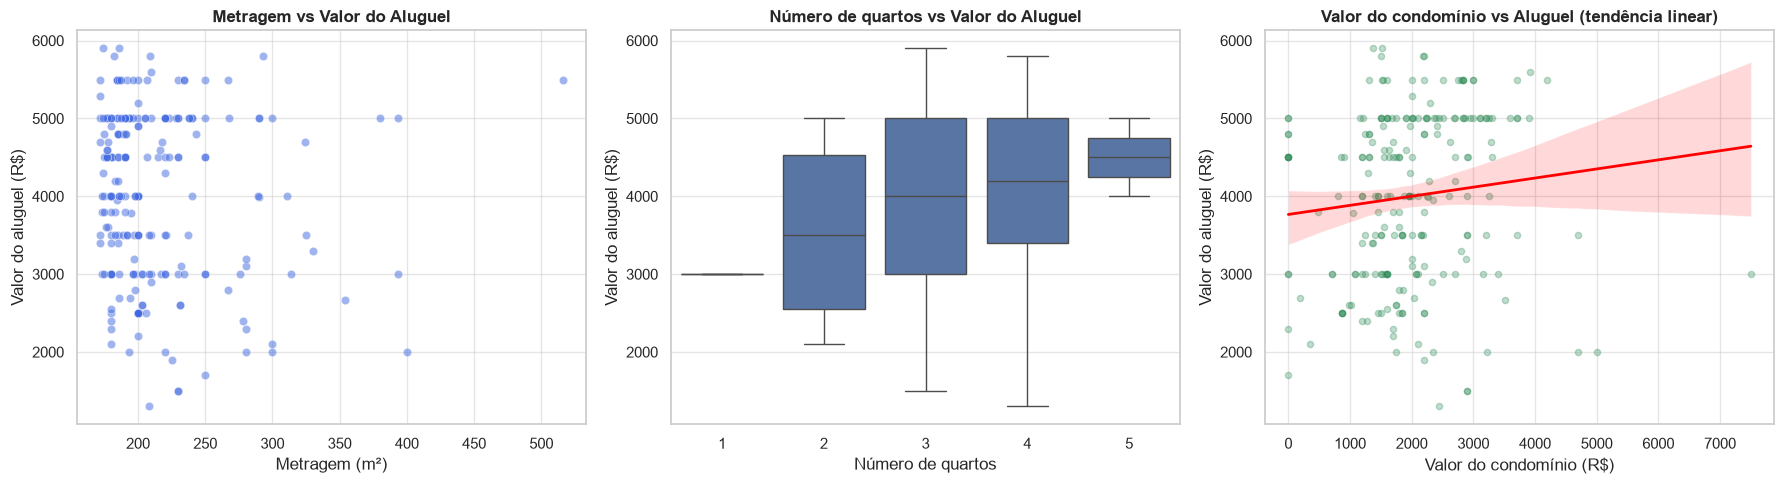

In [7]:
# Análise bivariada
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Metragem x Valor de aluguel
sns.scatterplot(data=df_clean, x='Metragem', y='Valor_Aluguel', alpha=0.5, ax=axes[0], color='royalblue')
axes[0].set_title('Metragem vs Valor do Aluguel', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Metragem (m²)')
axes[0].set_ylabel('Valor do aluguel (R$)')

# Número de quartos vs valor de aluguel
sns.boxplot(data=df_clean, x='N_Quartos', y='Valor_Aluguel', ax=axes[1])
axes[1].set_title('Número de quartos vs Valor do Aluguel', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de quartos')
axes[1].set_ylabel('Valor do aluguel (R$)')

# Valor do condomínio vs Valor do aluguel (reta tendência)
sns.regplot(data=df_clean, x='Valor_Condominio', y='Valor_Aluguel', ax=axes[2], color='seagreen', scatter_kws={'alpha': 0.3, 's': 20}, line_kws={'color': 'red', 'linewidth': 2})
axes[2].set_title('Valor do condomínio vs Aluguel (tendência linear)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Valor do condomínio (R$)')
axes[2].set_ylabel('Valor do aluguel (R$)')

plt.tight_layout()
plt.show()

**INSIGHTS:**

Gráfico 1: À medida que a metragem aumenta, o preço do aluguel acompanha o crescimento. Existe uma tendência linear bem definida. É um indicativo que a variável 'Metragem' será uma das variáveis explicativas no modelo.

Gráfico 2: Imóveis de 3 a 4 quartos possuem um patamar de preço significativamente superior aos imóveis de 1 a 2 quartos, portanto, observa-se uma elevação progressiva das medianas do preço do aluguel.

Gráfico 3: Com a linha de regressão, é evidenciado o comportamento linear positivo entre o custo do condomínio e o aluguel. Condomínios mais caros estão diretamente associados a imoveis de alguel mais caro, como é possível ver a partir da inclinação ascendente da reta vermelha.

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




--- Correlação das variáveis com o Valor do Aluguel ---


,Valor_Aluguel
Valor_Aluguel,1.000000
N_Vagas,0.209463
N_Suites,0.191529
N_banheiros,0.174066
Valor_Condominio,0.107422
N_Quartos,0.106094
Metragem,-0.084385


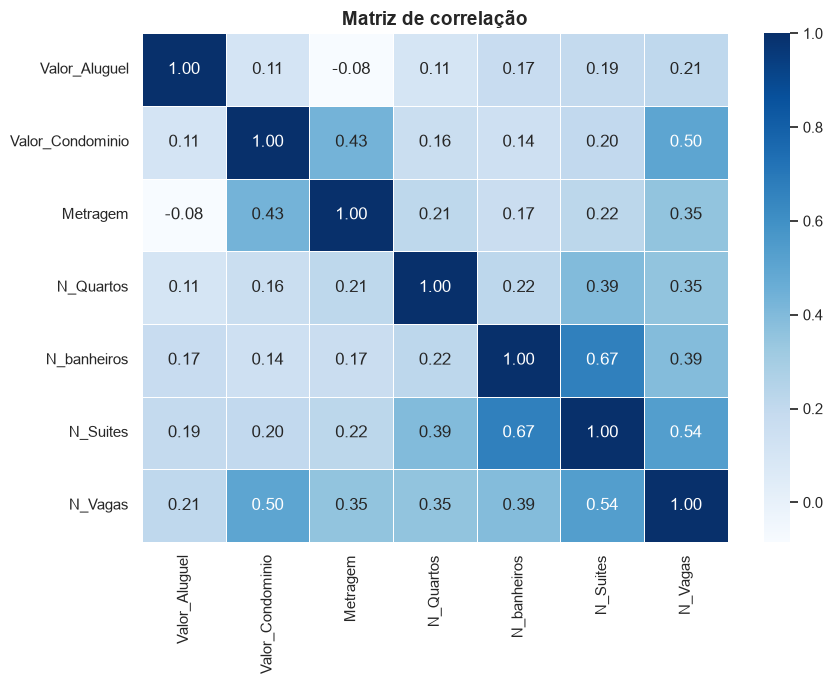

In [8]:
# Calcula a matriz de correlação
matriz_correlacao = df_clean.corr()

# Exibe a tabela ordenada em relação à variável alvo
print("--- Correlação das variáveis com o Valor do Aluguel ---")
display(matriz_correlacao[['Valor_Aluguel']].sort_values(by=['Valor_Aluguel'], ascending=False))

# Plota o heatmap da matriz de correlação
plt.figure(figsize=(9, 7))
sns.heatmap(matriz_correlacao, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Matriz de correlação', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Variáveis mais relevantes para o Valor_Aluguel: N_Vagas ($0,21$), N_Suites ($0,19$) e N_banheiros ($0,17$) apresentam os maiores coeficientes de correlação positiva em relação ao valor da locação.

Identificação de Multicolinearidade: Observam-se forte dependência linear entre as variáveis explicativas, destacando-se as pares: N_Suites e N_banheiros ($r = 0,67$)   N_Suites e N_Vagas ($r = 0,54$)   N_Vagas e Valor_Condominio ($r = 0,50$)

Essa alta correlação cruzada entre os atributos estruturais indica redundância de informação (multicolinearidade).


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [9]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [10]:
# Divisão de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificação do tamanho de cada conjunto
print(f"Tamanho total da base: {len(df)}")
print(f"Conjunto de Treino (X_train): {X_train.shape[0]} linhas")
print(f"Conjunto de Treino (y_train): {y_train.shape[0]} linhas")

Tamanho total da base: 7203
Conjunto de Treino (X_train): 5762 linhas
Conjunto de Treino (y_train): 5762 linhas


# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [11]:
X = X_train[['Metragem']]  # Variável independente (características)
y = y_train  # Variável dependente (rótulo)

In [12]:
# Instanciando o modelo
modelo_regressao = LinearRegression()

# Treina o modelo apenas com os dados de treino
modelo_regressao.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[34.47]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Metragem']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-97
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [13]:
# Extraindo os coeficientes
intercepto = modelo_regressao.intercept_
coeficente = modelo_regressao.coef_[0]

# Exibição de valores isolados
print(f"Intercepto: {intercepto}")
print(f"Coeficente: {coeficente}")

print("\n" + "="*50 + "\n")

Intercepto: -96.99896039932219
Coeficente: 34.473970893248726




Nossa equação seria: Valor_Aluguel = -97.00 + (34.47 * Metragem)

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [14]:
# Filtra apenas a coluna 'Metragem'
X_train_simples = X_train[['Metragem']]

# Fazendo predições utilizando a variável metragem do treino
y_pred_train = modelo_regressao.predict(X_train_simples)

# Calcula o R²
r2_train = modelo_regressao.score(X_train_simples, y_train)

print(f"R² no conjunto de treinamento: {r2_train:.4f}")
print(f"R² em percentual: {r2_train*100:.2f}%")

R² no conjunto de treinamento: 0.5214
R² em percentual: 52.14%


Um R²=0.52 indica que a variável Metragem consegue explicar 52% do comportamento do valor aluguel. É um resultado moderado para uma regressão linear simples, confirmando que metragem é um fator relevante. No entanto, 48% da variação do preço permanece sem explicação, isso significa que a metragem isoladamente não é suficiente para precificar imóveis com alta precisão. A utilização de uma regressão linear múltipla pode elevar a capacidade preditiva do modelo.

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

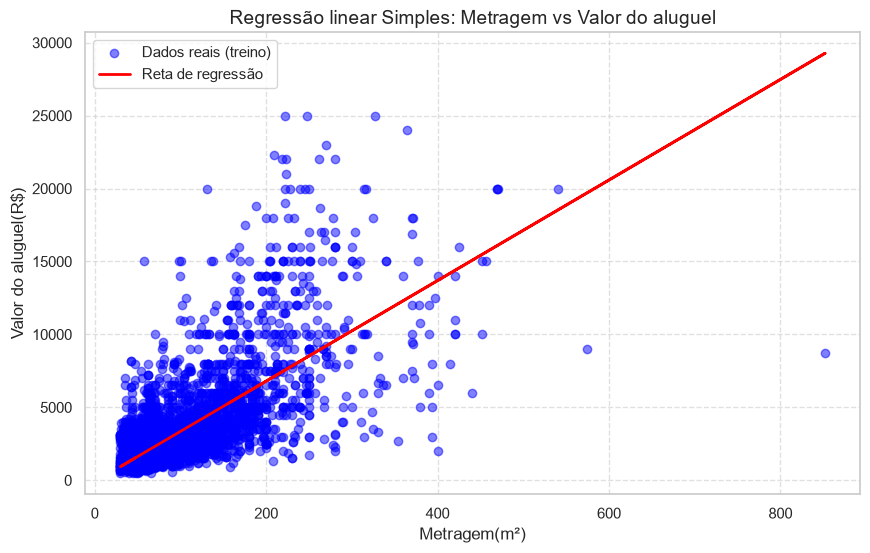

In [19]:
plt.figure(figsize=(10,6))

# Gráfico de dispersão (pontos reais)
plt.scatter(X_train['Metragem'], y_train, color='blue', alpha=0.5, label='Dados reais (treino)')

# Reta de regressão (Predição)
plt.plot(X_train['Metragem'], y_pred_train, color='red', linewidth=2, label='Reta de regressão')

# Personalizações
plt.title('Regressão linear Simples: Metragem vs Valor do aluguel', fontsize=14)
plt.xlabel('Metragem(m²)', fontsize=12)
plt.ylabel('Valor do aluguel(R$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

**INSIGHTS:** A inclinação da reta indica relação direta entre área e preço. É possível perceber, portanto, que imóveis maiores tendem a ter alugueis mais caros.

É possível perceber também que conforme a metragem aumenta, a dispersão dos pontos em relação a reta de dispersão também aumentam significativamente. Isso significa que para imóveis pequenos, o preço fica concentrado e próximo da reta, e para imóveis grandes, a variação aumenta.

A reta capta bem a tendência de crescimento do valor do aluguel em relação à área. Contudo, a variação restante nos pontos limpos reforça que a remoção de outliers isoladamente não resolve a falta de informação do modelo, justificando a transição para uma Regressão Linear Múltipla.

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [20]:
X_test = X_test[['Metragem']]  # Variável independente (características)
y_test = y_test  # Variável dependente (rótulo)

In [21]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = modelo_regressao.predict(X_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = modelo_regressao.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)


Coeficiente de Determinação (R²) nos Dados de Teste: 0.5697993791211697


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

O modelo consegue explicar cerca de 52% a 57% da variação nos preços dos alugueis se baseando unicamente na metragem. Imagino que não seja ruim para um modelo de apenas uma variável, mas deixa praticamente metade do comportamento do preço 'no escuro'. Pelo fato de estagnar em 50% confrima pra mim que a metragem isolada é insuficiente para prever o valor exato. O modelo atinge o limite porque faltariam informações essenciais do imóvel. É um modelo equilibrado, mas com teto limitado.

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [22]:
 # Definindo variáveis
 y = df['Valor_Aluguel']
 x = df.drop(columns=['Valor_Aluguel'])

 # Separando a base em treino e teste
 x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

 # Confirmar o tamanho das bases
 print(f"Tamanho da base X (Treino): {x_train.shape}")
 print(f"Tamanho da base X (Teste): {x_test.shape}")

Tamanho da base X (Treino): (5762, 6)
Tamanho da base X (Teste): (1441, 6)


B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [24]:
# Instanciação
modelo_multiplo = LinearRegression()

# Treinando o modelo apenas com base de treino
modelo_multiplo.fit(x_train, y_train)

# Exibir os coeficientes aprendidos pelo modelo
print("Intercepto: ", modelo_multiplo.intercept_)
print("\nCoeficientes das variáveis (b1, b2, ...):")
for col, coef in zip(x_train.columns, modelo_multiplo.coef_):
    print(f" - {col}: {coef:.4f}")

Intercepto:  435.29273156066074

Coeficientes das variáveis (b1, b2, ...):
 - Valor_Condominio: 0.7840
 - Metragem: 20.6814
 - N_Quartos: -649.1219
 - N_banheiros: 223.7115
 - N_Suites: 340.3379
 - N_Vagas: 501.2463


C) Traga o valor do R quadrado e avalie o valor encontrado.

In [26]:
# Calculo do R²
r2_train = modelo_multiplo.score(x_train, y_train)

print(f"R² no conjunto de treinamento: {r2_train:.4f}")
print(f"R² em percentual: {r2_train*100:.2f}%")

R² no conjunto de treinamento: 0.5958
R² em percentual: 59.58%


D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [27]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = modelo_multiplo.predict(x_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = modelo_multiplo.score(_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)

Coeficiente de Determinação (R²) nos Dados de Teste: 0.6400782589585375


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

O modelo de regressão linear múltipla é superior ao modelo de regressão linear simples. Enquanto o R² de treino e teste do modelo simples variou entre 0.52 a 0.56, o R² do modelo múltiplo já superou o modelo simples apenas em treino com 0.59 e chegou a 0.64 em teste.

Tais avanços podem ter acontecido por conta de um número maior de fatores. Com a inclusão de mais variáveis independentes no modelo, é possível fornecer ao alogritmo um conjunto mais completo de características. Cada nova variável relevante ajuda a explicar uma fatia da variância do preço que a variável única da regressão simples não conseguia capturar sozinha. Outro fator que pode explicar o avanço foi o aumento na base de teste.Isso demonstra que o modelo não memorizou os dados de treino (não sofreu de overfitting), mantendo uma excelente capacidade de generalizar previsões para dados totalmente novos que ele nunca tinha visto antes.